# HW_8. CuPy
## Roman Branovets, Skoltech, 2025

In [232]:
!nvidia-smi

Tue Dec  9 17:39:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             30W /   70W |    8182MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [233]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [234]:
!pip install cupy-cuda12x

##Task 1:
1. An explanation is given of what is the difference between cupy and numpy. How does cupy handle data transfers between cpu and gpu? (1 point).
2. Function saxpy that runs on GPU using cupy rawkernel (!!!) is provided (1 point).
3. Graph (OX - size of arrays, OY - computation time) is given. Plot numpy and cupy implementations (2 points).

The main difference between cupy and numpy is that cupy runs on the GPU, while numpy runs on the CPU. GPU computing has higher throughput, but less latency than CPU computing. Cupy also stores data in GPU memory, and numpy in CPU memory. CuPy uses memory pool for memory allocations by default. The memory pool significantly improves the performance by mitigating the overhead of memory allocation and CPU/GPU synchronization.
CPU allocates memory, copy data to GPU and launch kernel

Move arrays to a device:
cupy.asarray() can be used to move a numpy.ndarray, a list, or any object that can be passed to numpy.array() to the current device (GPU).
Move array from a device to the host:
Moving a device (GPU) array to the host(CPU) can be done by cupy.asnumpy() and cupy.ndarray.get().
We have to minimize copying between the CPU and GPU.


In [235]:
import cupy as cp

saxpy = cp.RawKernel(r'''
extern "C" __global__
void saxpy(const float* x, const float* y, const float a, float* z) {
    int bid = blockIdx.z * gridDim.x * gridDim.y + blockIdx.y * gridDim.x + blockIdx.x;
    int tid = threadIdx.z * blockDim.x * blockDim.y + threadIdx.y * blockDim.x + threadIdx.x;
    int gid = tid + bid * blockDim.x * blockDim.y * blockDim.z;

    z[gid] = a * x[gid] + y[gid];
}
''', 'saxpy')

x = cp.linspace(0, 1000, 2**20, dtype=cp.float32)
y = cp.linspace(0, 1000, 2**20, dtype=cp.float32)
z = cp.empty((2**20), dtype=cp.float32)
a = cp.float32(2.0)
saxpy((256,2,2), (512,2,1), (x, y, a, z))

In [236]:
print(z)

[0.0000000e+00 2.8610257e-03 5.7220515e-03 ... 2.9999944e+03 2.9999971e+03
 3.0000000e+03]


In [237]:
import numpy as np
n_x = np.linspace(0, 1000, 2**20, dtype=np.float32)
n_y = np.linspace(0, 1000, 2**20, dtype=np.float32)
n_a = np.float32(2.0)
n_z = n_a * n_x + n_y
print(n_z)

[0.0000000e+00 2.8610257e-03 5.7220515e-03 ... 2.9999944e+03 2.9999971e+03
 3.0000000e+03]


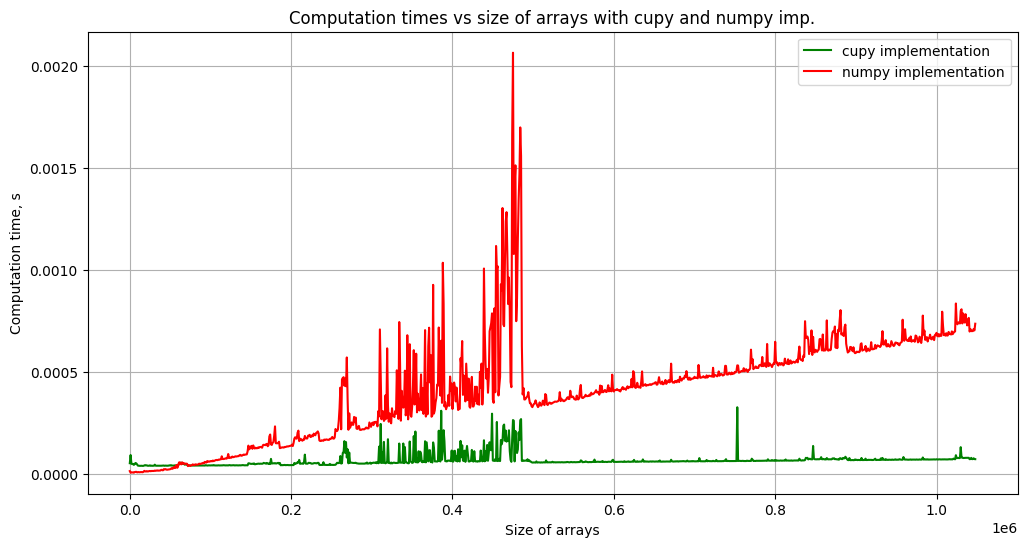

In [238]:
#time measuremets
from time import time
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp

saxpy = cp.RawKernel(r'''
extern "C" __global__
void saxpy(const float* x, const float* y, const float a, int N, float* z) {
    int bid = blockIdx.z * gridDim.x * gridDim.y + blockIdx.y * gridDim.x + blockIdx.x;
    int tid = threadIdx.z * blockDim.x * blockDim.y + threadIdx.y * blockDim.x + threadIdx.x;
    int gid = tid + bid * blockDim.x * blockDim.y * blockDim.z;
    if (gid < N) {
    z[gid] = a * x[gid] + y[gid];
    }
}
''', 'saxpy')

sizes = np.arange(2**5, 2**20, 1000)
n_means = []
c_means = []


for i in sizes:
    c_x = cp.linspace(0, 1000, i, dtype=cp.float32)
    c_y = cp.linspace(0, 1000, i, dtype=cp.float32)
    c_z = cp.empty((i), dtype=cp.float32)
    c_a = cp.float32(2.0)
    c_times = []
    for j in range(50):
        c_time0 = time()
        saxpy((256,2,2), (512,2,1), (c_x, c_y, c_a, cp.int32(i), c_z))
        cp.cuda.Device().synchronize()
        c_time1 = time()
        c_time = c_time1-c_time0
        c_times.append(c_time)
    c_means.append(np.mean(c_times[10:]))
    n_x = np.linspace(0, 1000, i, dtype=np.float32)
    n_y = np.linspace(0, 1000, i, dtype=np.float32)
    n_a = np.float32(2.0)
    n_times = []
    for k in range(50):
        n_time0 = time()
        n_z = n_a * n_x + n_y
        n_time1 = time()
        n_time = n_time1-n_time0
        n_times.append(n_time)
    n_means.append(np.mean(n_times))
plt.figure(figsize=(12,6))
plt.plot(sizes, c_means, label='cupy implementation', color="green")
plt.plot(sizes, n_means, label='numpy implementation', color="red")
plt.grid()
plt.legend()
plt.title("Computation times vs size of arrays with cupy and numpy imp.")
plt.xlabel("Size of arrays")
plt.ylabel("Computation time, s")
plt.show()

## Task 2. Image blur

1. Before and after pictures are given (any 100x100 image) (1 point).
2. Cupy version computation time is given (2 points).
3. Numpy version computation time is given (1 point).


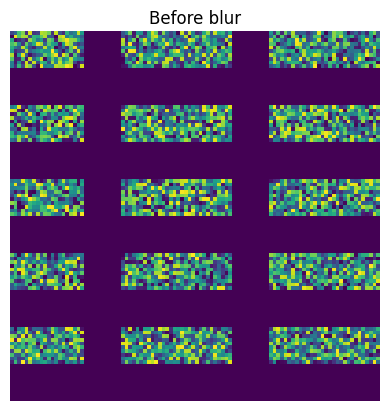

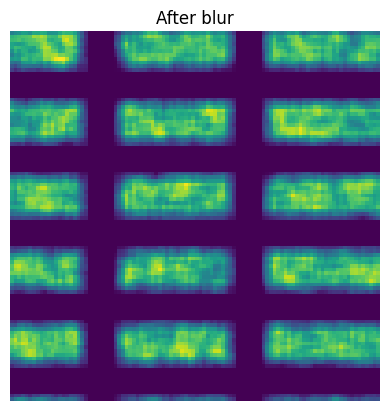

In [239]:
import numpy as np
import time

N = 100
image = np.random.rand(N,N)
image[10:20, :] = 0
image[30:40, :] = 0
image[50:60, :] = 0
image[70:80, :] = 0
image[90:100, :] = 0
image[:, 20:30] = 0
image[:, 60:70] = 0
plt.imshow(image)
plt.axis('off')
plt.title('Before blur')
plt.show()


width = 4
pattern = np.ones((width, width))
pattern = np.pad(pattern, N//2-width//2)
sp_image = np.fft.rfft2(image)
sp_pattern = np.fft.rfft2(pattern)
sp_blur = sp_image * sp_pattern
image_blur = np.fft.ifftshift(np.fft.irfft2(sp_blur))
plt.imshow(image_blur)
plt.axis('off')
plt.title('After blur')
plt.show()

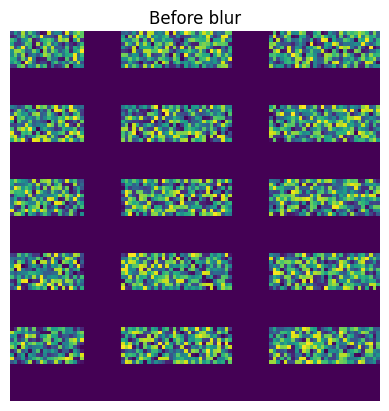

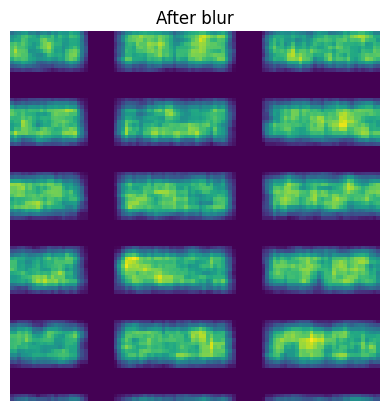

In [240]:
import cupy as сp
import time

N = 100
image = cp.random.rand(N,N)
image[10:20, :] = 0
image[30:40, :] = 0
image[50:60, :] = 0
image[70:80, :] = 0
image[90:100, :] = 0
image[:, 20:30] = 0
image[:, 60:70] = 0
imageCPU = image.get()
plt.imshow(imageCPU)
plt.axis('off')
plt.title('Before blur')
plt.show()
width = 4
pattern = cp.ones((width, width))
pattern = cp.pad(pattern, N//2-width//2)
sp_image = cp.fft.rfft2(image)
sp_pattern = cp.fft.rfft2(pattern)
sp_blur = sp_image * sp_pattern
image_blur = cp.fft.ifftshift(cp.fft.irfft2(sp_blur))
image_blurCPU = image_blur.get()
plt.imshow(image_blurCPU)
plt.axis('off')
plt.title('After blur')
plt.show()

In [241]:
def cuda_prof():
    ctimes = []
    N = 100
    image = cp.random.rand(N,N)
    image[10:20, :] = 0
    image[30:40, :] = 0
    image[50:60, :] = 0
    image[70:80, :] = 0
    image[90:100, :] = 0
    image[:, 20:30] = 0
    image[:, 60:70] = 0
    width = 4
    pattern = cp.ones((width, width))
    pattern = cp.pad(pattern, N//2-width//2)
    for i in range(50):
        cp_time0 = time.perf_counter()
        sp_image = cp.fft.rfft2(image)
        sp_pattern = cp.fft.rfft2(pattern)
        sp_blur = sp_image * sp_pattern
        image_blur = cp.fft.ifftshift(cp.fft.irfft2(sp_blur))
        cp.cuda.Device().synchronize()
        cp_time1 = time.perf_counter()
        ctimes.append(cp_time1 - cp_time0)
    return np.mean(ctimes[10:])

print(f"CuPy version computation time : {(cuda_prof())*1000} ms")

CuPy version computation time : 0.42034084999613697 ms


In [242]:
def numpy_prof():
    ntimes = []
    N = 100
    image = np.random.rand(N,N)
    image[10:20, :] = 0
    image[30:40, :] = 0
    image[50:60, :] = 0
    image[70:80, :] = 0
    image[90:100, :] = 0
    image[:, 20:30] = 0
    image[:, 60:70] = 0
    width = 4
    pattern = np.ones((width, width))
    pattern = np.pad(pattern, N//2-width//2)
    for i in range(50):
        np_time0 = time.perf_counter()
        sp_image = np.fft.rfft2(image)
        sp_pattern = np.fft.rfft2(pattern)
        sp_blur = sp_image * sp_pattern
        image_blur = np.fft.ifftshift(np.fft.irfft2(sp_blur))
        np_time1 = time.perf_counter()
        ntimes.append(np_time1 - np_time0)
    return np.mean(ntimes)

print(f"NumPy version computation time : {(numpy_prof())*1000} ms")

NumPy version computation time : 0.4445260198917822 ms
